# DINOHead의 출력 로짓 $z_k$ 는 "프로토타입과의 코사인 유사도"다

필요 패키지: `torch` (2.4), `numpy`, `plotly` (6.9), `kaleido`

DINO의 헤드는

$$
h_\theta(y) \;=\; W\,\tilde{u},
\qquad
\tilde{u} \;=\; \frac{\mathrm{MLP}(y)}{\lVert \mathrm{MLP}(y)\rVert_2}
\;\in\; \mathbb{S}^{d-1}
$$

로 구성된다. 마지막 층은 `nn.utils.weight_norm` 으로 재매개화되어 있어서
$W$ 의 각 행이

$$
w_k \;=\; g_k \,\frac{v_k}{\lVert v_k \rVert}
$$

이다. DINO는 `weight_g.data.fill_(1)` 로 $g_k = 1$ 을 넣고,
`norm_last_layer=True` 면 `requires_grad=False` 로 **고정**한다. 그러면

$$
z_k \;=\; w_k^\top \tilde u \;=\; \frac{v_k^{\top}\tilde u}{\lVert v_k \rVert}
\;=\; \cos\angle(v_k,\ \tilde u) \;\in\; [-1, 1]
$$

즉 로짓 벡터 $z \in \mathbb{R}^K$ 는 **$K$ 개 프로토타입 방향 $v_k$ 와의
코사인 유사도 목록**이고, $\arg\max_k z_k$ 는 "이 샘플이 어느 프로토타입에
배정되는가" — 즉 **소프트 클러스터링의 클러스터 할당**으로 읽힌다.

아래에서 실제 `DINOHead` 를 만들어 이 등식을 하나씩 확인한다.

In [1]:
import os
import sys
import warnings

import numpy as np
import torch
import torch.nn.functional as F

warnings.filterwarnings("ignore")  # torch 2.4 weight_norm deprecation 경고 숨김

sys.path.insert(0, "/home/sungwoo/projects/swcho/dino")
from vision_transformer import DINOHead  # noqa: E402

torch.manual_seed(0)
np.random.seed(0)

HERE = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()


def _show(fig):
    try:
        from IPython import get_ipython
        if get_ipython() is not None:  # VSCode 셀/Jupyter에서만 렌더링
            fig.show()
    except ImportError:
        pass


print("torch", torch.__version__)

torch 2.4.0+cu121


## 1. 작은 DINOHead 하나 만들어 내부를 들여다보기

`in_dim=32` (백본 CLS 차원 대역), `out_dim=16` ($K$, 프로토타입 개수),
`bottleneck_dim=8` ($d$, 정규화가 일어나는 구면의 차원).

In [2]:
K, D_BOTTLE = 16, 8
head = DINOHead(in_dim=32, out_dim=K, bottleneck_dim=D_BOTTLE, norm_last_layer=True)
head.eval()

last = head.last_layer
print("last_layer          :", last)
print("weight_g  shape     :", tuple(last.weight_g.shape), " requires_grad =", last.weight_g.requires_grad)
print("weight_v  shape     :", tuple(last.weight_v.shape), " requires_grad =", last.weight_v.requires_grad)
print("weight_g  값 (앞 5개):", last.weight_g.detach().flatten()[:5].tolist())

last_layer          : Linear(in_features=8, out_features=16, bias=False)
weight_g  shape     : (16, 1)  requires_grad = False
weight_v  shape     : (16, 8)  requires_grad = True
weight_g  값 (앞 5개): [1.0, 1.0, 1.0, 1.0, 1.0]


핵심은 두 가지다.

- `weight_g` 가 전부 $1$ → 행 노름 $\lVert w_k \rVert = g_k = 1$ (단위 벡터)
- `weight_g.requires_grad = False` → 학습 중에도 계속 $1$ (그래서 로짓 스케일이 구조적으로 묶인다)

그리고 `bias=False` 이므로 로짓에 상수항도 없다. 남는 건 순수한 내적뿐.

In [3]:
with torch.no_grad():
    head(torch.zeros(1, 32))            # weight_norm 은 forward 시점에 w 를 재계산한다
    w = last.weight.detach()            # (16, 8)  실제로 쓰이는 W
    w_manual = last.weight_g.detach() * F.normalize(last.weight_v.detach(), dim=-1)

print("W == g * v/||v||    :", torch.allclose(w, w_manual, atol=1e-6))
print("행 노름 ||w_k|| 범위 :", f"[{w.norm(dim=1).min():.6f}, {w.norm(dim=1).max():.6f}]")
print("bias                :", last.bias)

W == g * v/||v||    : True
행 노름 ||w_k|| 범위 : [1.000000, 1.000000]
bias                : None


## 2. 로짓 = $\cos\angle(v_k, \tilde u)$ 임을 `torch.allclose` 로 확인

`forward` 를 손으로 재현한다: `mlp` → L2 정규화 → `last_layer`.
그리고 같은 값을 `F.cosine_similarity(u_tilde, v_k)` 로도 계산해 비교한다.

In [4]:
B = 5
y = torch.randn(B, 32)                       # 백본 CLS 토큰이라 치자

with torch.no_grad():
    u = head.mlp(y)                          # (B, 8)   bottleneck 표현
    u_tilde = F.normalize(u, dim=-1, p=2)    # (B, 8)   단위 구면 위로
    z = head.last_layer(u_tilde)             # (B, 16)  로짓
    z_fwd = head(y)                          # forward 전체 (같아야 함)

    v = last.weight_v                        # (16, 8)  프로토타입 "방향" (노름 자유)
    # 각 (샘플 b, 프로토타입 k) 쌍에 대해 코사인 유사도
    z_cos = F.cosine_similarity(u_tilde.unsqueeze(1), v.unsqueeze(0), dim=-1)   # (B, 16)
    # 정의식 그대로: v_k^T u~ / ||v_k||
    z_manual = (u_tilde @ v.T) / v.norm(dim=1)

print("u_tilde 노름        :", u_tilde.norm(dim=-1).tolist())
print("z == head(y)        :", torch.allclose(z, z_fwd, atol=1e-6))
print("z == cosine_sim     :", torch.allclose(z, z_cos, atol=1e-6))
print("z == v^T u~/||v||   :", torch.allclose(z, z_manual, atol=1e-6))
print("최대 절대 오차      :", (z - z_cos).abs().max().item())

u_tilde 노름        : [0.9999999403953552, 1.0, 0.9999999403953552, 1.0, 1.0]
z == head(y)        : True
z == cosine_sim     : True
z == v^T u~/||v||   : True
최대 절대 오차      : 1.7881393432617188e-07


세 계산이 모두 일치한다. 즉 DINOHead의 로짓은 **정의상 코사인 유사도**다.

## 3. 그래서 로짓 범위가 $[-1, 1]$ 에 갇힌다

In [5]:
print(f"z min = {z.min():.4f},  z max = {z.max():.4f}")
assert z.abs().max() <= 1.0 + 1e-5, "norm_last_layer 가 깨졌다"
print("로짓이 [-1, 1] 안 → 프로토타입 코사인 유사도로 해석 가능 ✔")

print("\n샘플 0 의 로짓 (K=16):")
print(np.round(z[0].numpy(), 3))

z min = -0.7290,  z max = 0.8107
로짓이 [-1, 1] 안 → 프로토타입 코사인 유사도로 해석 가능 ✔

샘플 0 의 로짓 (K=16):
[-0.162  0.089  0.054 -0.377 -0.248 -0.407  0.13   0.347  0.502 -0.309
 -0.132  0.35  -0.729 -0.492 -0.167 -0.444]


## 4. 대조군: `norm_last_layer=False` 로 만들고 $g_k$ 를 키우면?

`norm_last_layer=False` 면 `weight_g.requires_grad = True` 라서 학습 중
$g_k$ 가 1에서 떠날 수 있다. 그러면

$$
z_k \;=\; g_k \cdot \cos\angle(v_k,\ \tilde u)
$$

가 되어 **더 이상 코사인 유사도가 아니고**, 범위도 $[-1,1]$ 을 벗어난다.

`main_dino.py` 에서 teacher 헤드는 항상 기본값(`norm_last_layer=True`)이고,
student 헤드만 `--norm_last_layer` 로 열어 둔다. 원 저자 주석에 따르면
정규화를 풀면 성능이 조금 더 좋지만 **학습이 불안정해질 수 있어서**
ViT-S 에서는 `False`, ViT-B 에서는 `True` 를 썼다.

In [6]:
torch.manual_seed(0)
head_free = DINOHead(in_dim=32, out_dim=K, bottleneck_dim=D_BOTTLE, norm_last_layer=False)
head_free.eval()
print("weight_g.requires_grad =", head_free.last_layer.weight_g.requires_grad)

with torch.no_grad():
    z_before = head_free(y)
    print(f"g_k = 1  일 때  : min={z_before.min():.4f}  max={z_before.max():.4f}  |z|max={z_before.abs().max():.4f}")

    # 학습이 진행되어 g_k 가 커진 상황을 흉내낸다
    head_free.last_layer.weight_g.data.mul_(7.0)
    z_after = head_free(y)
    print(f"g_k = 7  일 때  : min={z_after.min():.4f}  max={z_after.max():.4f}  |z|max={z_after.abs().max():.4f}")
    print("[-1,1] 안에 있나:", bool(z_after.abs().max() <= 1.0))
    print("z_after == 7 * z_before :", torch.allclose(z_after, 7.0 * z_before, atol=1e-5))

weight_g.requires_grad = True
g_k = 1  일 때  : min=-0.7290  max=0.8107  |z|max=0.8107
g_k = 7  일 때  : min=-5.1033  max=5.6747  |z|max=5.6747
[-1,1] 안에 있나: False
z_after == 7 * z_before : True


## 5. $\arg\max_k z_k$ = "프로토타입 할당" (클러스터링 관점)

로짓이 코사인 유사도이므로, $\arg\max$ 는 **$\tilde u$ 와 각도가 가장 작은
프로토타입 방향**을 고르는 것과 같다. 이는 단위 구면 위에서의
스피리컬 $k$-means 할당과 정확히 같은 규칙이다.

In [7]:
with torch.no_grad():
    assign = z.argmax(dim=1)
    # 프로토타입 단위벡터와의 각도(도)로도 검증
    v_hat = F.normalize(v, dim=-1)
    angles_deg = torch.rad2deg(torch.arccos((u_tilde @ v_hat.T).clamp(-1, 1)))
    assign_by_angle = angles_deg.argmin(dim=1)

for b in range(B):
    print(f"샘플 {b}: argmax z = {assign[b].item():2d}  "
          f"(cos = {z[b, assign[b]]:.3f}, 각도 = {angles_deg[b, assign[b]]:.1f}°)  "
          f"| 최소각 프로토타입 = {assign_by_angle[b].item():2d}")
print("\nargmax(cos) == argmin(angle) :", torch.equal(assign, assign_by_angle))

샘플 0: argmax z =  8  (cos = 0.502, 각도 = 59.8°)  | 최소각 프로토타입 =  8
샘플 1: argmax z =  8  (cos = 0.656, 각도 = 49.0°)  | 최소각 프로토타입 =  8
샘플 2: argmax z =  3  (cos = 0.736, 각도 = 42.6°)  | 최소각 프로토타입 =  3
샘플 3: argmax z = 14  (cos = 0.811, 각도 = 35.8°)  | 최소각 프로토타입 = 14
샘플 4: argmax z =  6  (cos = 0.690, 각도 = 46.4°)  | 최소각 프로토타입 =  6

argmax(cos) == argmin(angle) : True


## 6. 2D 장난감 그림: 단위 원 위의 점 → 가장 가까운 프로토타입에 배정

$\tilde u$ 가 단위 구면 위에 있고 프로토타입도 방향뿐이므로, $d=2$ 로 줄이면
그림이 그대로 나온다. 아래 왼쪽 패널은 단위 원 위 점들을
$\arg\max_k \cos\angle(v_k, \tilde u)$ 로 색칠한 것 — 원이 각 프로토타입의
**각도 구간(보로노이 부채꼴)** 으로 쪼개진다.

In [8]:
K2 = 5
proto_ang = np.array([20.0, 85.0, 150.0, 225.0, 310.0])          # 프로토타입 방향(도)
proto = np.stack([np.cos(np.deg2rad(proto_ang)), np.sin(np.deg2rad(proto_ang))], axis=1)  # (5,2)

pt_ang = np.linspace(0, 360, 360, endpoint=False)
pts = np.stack([np.cos(np.deg2rad(pt_ang)), np.sin(np.deg2rad(pt_ang))], axis=1)          # (360,2)

cos2d = pts @ proto.T          # 둘 다 단위벡터 → 내적 = 코사인 유사도 = 로짓
owner = cos2d.argmax(axis=1)

print("2D 로짓 범위 :", f"[{cos2d.min():.3f}, {cos2d.max():.3f}]")
for k in range(K2):
    seg = pt_ang[owner == k]
    print(f"프로토타입 {k} (θ={proto_ang[k]:5.1f}°) 담당 점 {len(seg):3d}개, "
          f"각도 {seg.min():5.1f}° ~ {seg.max():5.1f}°")

2D 로짓 범위 : [-1.000, 1.000]
프로토타입 0 (θ= 20.0°) 담당 점  68개, 각도   0.0° ~ 359.0°
프로토타입 1 (θ= 85.0°) 담당 점  65개, 각도  53.0° ~ 117.0°
프로토타입 2 (θ=150.0°) 담당 점  70개, 각도 118.0° ~ 187.0°
프로토타입 3 (θ=225.0°) 담당 점  80개, 각도 188.0° ~ 267.0°
프로토타입 4 (θ=310.0°) 담당 점  77개, 각도 268.0° ~ 344.0°


## 7. 온도 $\tau$: 같은 로짓이라도 분포는 완전히 달라진다

로짓의 절대 스케일이 $[-1,1]$ 로 묶여 있으므로 softmax를 그냥 쓰면
분포가 거의 평평하다. DINO가 $\tau_s = 0.1$, $\tau_t = 0.04{\sim}0.07$ 같은
**작은 온도**를 쓰는 이유가 여기 있다.

$$
P_k \;=\; \frac{\exp(z_k/\tau)}{\sum_{j} \exp(z_j/\tau)}
$$

In [9]:
z0 = z[0]                                   # 샘플 0 의 로짓 (K=16)
rows = []
for tau in (1.0, 0.1, 0.07, 0.04):
    p = F.softmax(z0 / tau, dim=-1)
    ent = -(p * p.clamp_min(1e-12).log()).sum()
    rows.append((tau, p))
    print(f"tau={tau:<5} max p = {p.max():.4f}   상위3 합 = {p.topk(3).values.sum():.4f}   "
          f"엔트로피 = {ent:.4f} nats  (균등 = {np.log(K):.4f})")

tau=1.0   max p = 0.1106   상위3 합 = 0.3002   엔트로피 = 2.7154 nats  (균등 = 2.7726)
tau=0.1   max p = 0.6721   상위3 합 = 0.9618   엔트로피 = 1.0063 nats  (균등 = 2.7726)
tau=0.07  max p = 0.8112   상위3 합 = 0.9923   엔트로피 = 0.6512 nats  (균등 = 2.7726)
tau=0.04  max p = 0.9585   상위3 합 = 0.9999   엔트로피 = 0.2022 nats  (균등 = 2.7726)


## 8. 시각화 (expy.png)

- 왼쪽: 단위 원 위의 점 → 가장 코사인이 큰 프로토타입에 배정 (색 = 할당)
- 오른쪽: 같은 로짓에 대한 $\tau$ 별 softmax 분포

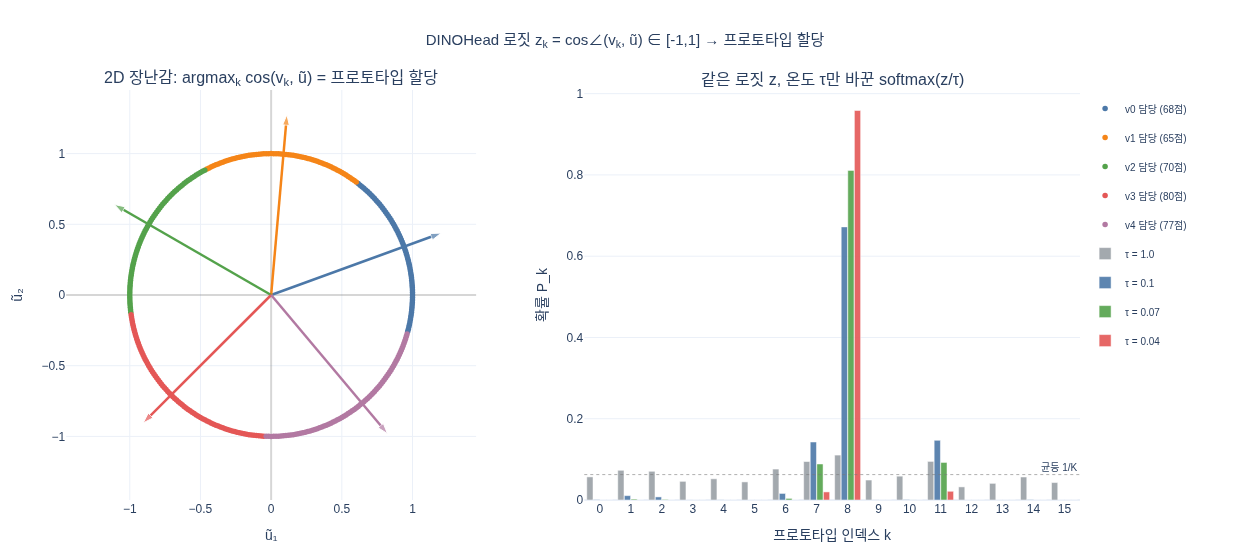

saved: /home/sungwoo/projects/swcho/dino/fm/training/.fm/hints/a8053a7e-a1ac-4db7-8c41-f956d3302b91/expy.png


In [10]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

PAL = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#B279A2"]

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        "2D 장난감: argmax<sub>k</sub> cos(v<sub>k</sub>, ũ) = 프로토타입 할당",
        "같은 로짓 z, 온도 τ만 바꾼 softmax(z/τ)",
    ),
    column_widths=[0.46, 0.54],
    horizontal_spacing=0.10,
)

# ── 왼쪽: 단위 원 + 프로토타입 방향 + 할당 색
fig.add_trace(go.Scatter(
    x=np.cos(np.linspace(0, 2 * np.pi, 361)), y=np.sin(np.linspace(0, 2 * np.pi, 361)),
    mode="lines", line=dict(color="rgba(130,130,130,0.35)", width=1),
    hoverinfo="skip", showlegend=False), row=1, col=1)

for k in range(K2):
    m = owner == k
    fig.add_trace(go.Scatter(
        x=pts[m, 0], y=pts[m, 1], mode="markers",
        marker=dict(size=5.5, color=PAL[k]),
        name=f"v{k} 담당 ({m.sum()}점)",
        legendgroup=f"v{k}",
        hovertemplate=f"할당 = v{k}<br>cos = %{{customdata:.3f}}<extra></extra>",
        customdata=cos2d[m, k]), row=1, col=1)
    # 프로토타입 방향 화살표(원점→v_k)
    fig.add_trace(go.Scatter(
        x=[0, proto[k, 0] * 1.28], y=[0, proto[k, 1] * 1.28], mode="lines+markers",
        line=dict(color=PAL[k], width=2.5),
        marker=dict(size=[0, 11], symbol="arrow", angleref="previous", color=PAL[k]),
        legendgroup=f"v{k}", showlegend=False,
        hovertemplate=f"프로토타입 v{k}<br>θ = {proto_ang[k]:.0f}°<extra></extra>"), row=1, col=1)

fig.update_xaxes(range=[-1.45, 1.45], zeroline=True, zerolinecolor="rgba(120,120,120,0.3)",
                 constrain="domain", title_text="ũ₁", row=1, col=1)
fig.update_yaxes(range=[-1.45, 1.45], zeroline=True, zerolinecolor="rgba(120,120,120,0.3)",
                 scaleanchor="x", scaleratio=1, title_text="ũ₂", row=1, col=1)

# ── 오른쪽: tau 별 softmax 분포
TAU_COL = {1.0: "#9AA0A6", 0.1: "#4C78A8", 0.07: "#54A24B", 0.04: "#E45756"}
for tau, p in rows:
    fig.add_trace(go.Bar(
        x=np.arange(K), y=p.numpy(), name=f"τ = {tau}",
        marker_color=TAU_COL[tau], opacity=0.9,
        hovertemplate="k=%{x}<br>p=%{y:.4f}<extra>τ=" + str(tau) + "</extra>"), row=1, col=2)

fig.add_hline(y=1.0 / K, line=dict(color="rgba(120,120,120,0.6)", width=1, dash="dot"),
              annotation_text="균등 1/K", annotation_font_size=10, row=1, col=2)
fig.update_xaxes(title_text="프로토타입 인덱스 k", dtick=1, row=1, col=2)
fig.update_yaxes(title_text="확률 P_k", row=1, col=2)

fig.update_layout(
    title=dict(text="DINOHead 로짓 z<sub>k</sub> = cos∠(v<sub>k</sub>, ũ) ∈ [-1,1] → 프로토타입 할당",
               x=0.5, font=dict(size=15)),
    barmode="group", bargap=0.15, bargroupgap=0.05,
    width=1250, height=560,
    legend=dict(font=dict(size=10), yanchor="top", y=0.99, xanchor="left", x=1.005),
    template="plotly_white", margin=dict(l=60, r=170, t=90, b=60),
)

_show(fig)

png_path = os.path.join(HERE, "expy.png")
fig.write_image(png_path, scale=2)
print("saved:", png_path)

## 정리

| 요소 | 역할 |
|---|---|
| `F.normalize(x, dim=-1)` | $\tilde u$ 를 단위 구면 위로 → 입력 쪽 노름 제거 |
| `weight_norm` + `weight_g=1` (고정) | $\lVert w_k \rVert = 1$ → 프로토타입 쪽 노름 제거 |
| `bias=False` | 상수항 제거 |

세 가지가 합쳐져서 로짓은 **순수한 방향 비교**, 즉
$z_k = \cos\angle(v_k, \tilde u) \in [-1, 1]$ 이 된다.
따라서 $z$ 는 "$K$ 개 프로토타입에 대한 유사도 점수표"이고,
$\mathrm{softmax}(z/\tau)$ 는 **소프트 클러스터 할당 분포**,
$\arg\max_k z_k$ 는 **하드 할당**으로 읽는 것이 자연스럽다.
스케일이 구조적으로 $[-1,1]$ 에 묶여 있어 한 프로토타입이 노름을 키워
softmax를 독식하는 붕괴 경로가 처음부터 막혀 있다.